# Vodafone Music Subscription Prediction

## Sprint 2 — Baseline Models

**Goal of this notebook:**

Train and evaluate 3 baseline models on the feature-engineered dataset.
Compare their performance using ROC-AUC, find the best baseline, and
identify what to improve in Sprint 3.

**Models:**
1. Logistic Regression (linear baseline)
2. Random Forest (tree ensemble)
3. LightGBM (gradient boosting — industry standard for tabular data)

**Notebook outline:**
1. Setup & Data Loading
2. Preprocessing Pipeline
3. Train / Validation Split
4. Model Training & Evaluation
5. ROC Curves Comparison
6. Feature Importance
7. Error Analysis
8. Results Summary

### 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM not installed. Run: pip install lightgbm')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

df = pd.read_csv('../data/processed/train_features.csv')

# Drop sum3 columns — mean3 carries identical information (mean = sum/3)
# Keeping both doubles the column count with zero new signal
sum3_cols = [c for c in df.columns if c.endswith('_sum3')]
df.drop(columns=sum3_cols, inplace=True)
print(f'Dropped {len(sum3_cols)} _sum3 columns (duplicates of _mean3)')
print('Shape after sum3 cleanup:', df.shape)
print('Target rate:', df['target'].mean().round(4))

Dropped 73 _sum3 columns (duplicates of _mean3)
Shape after sum3 cleanup: (70000, 576)
Target rate: 0.0757


### 2. Preprocessing Pipeline

We prepare features for modeling:
- Drop columns that must not go into a model (`id`, high-cardinality raw categoricals)
- Separate features (`X`) from target (`y`)
- For Logistic Regression: apply `StandardScaler` inside a Pipeline
- For tree-based models: no scaling needed


In [2]:
# Columns to drop: raw high-cardinality categoricals (we have target-encoded version)
DROP_COLS = ['manufacturer_category']  # replaced by manufacturer_category_te
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

X = df.drop(columns=['target'] + DROP_COLS)
y = df['target']

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')
print(f'Positive class: {y.mean():.4f} ({y.sum()} samples)')
print()
print('Any NaNs in X:', X.isna().sum().sum())
print('Any inf in X: ', np.isinf(X.values).sum())

# Replace any inf values (can appear in log features)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
print('After cleaning — NaNs:', X.isna().sum().sum())

Features: 574
Samples:  70000
Positive class: 0.0757 (5301 samples)

Any NaNs in X: 0
Any inf in X:  0
After cleaning — NaNs: 0


### 3. Train / Validation Split

We use **Stratified 5-Fold Cross-Validation** to get reliable performance estimates
while preserving the class ratio in each fold.

We also hold out a fixed 20% validation set for final comparison and plots.


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} samples  |  Val: {X_val.shape[0]:,} samples')
print(f'Train positive rate: {y_train.mean():.4f}')
print(f'Val   positive rate: {y_val.mean():.4f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 56,000 samples  |  Val: 14,000 samples
Train positive rate: 0.0757
Val   positive rate: 0.0757


### 4. Model Training & Evaluation

In [4]:
results = {}  # Store results for comparison

# ── Model 1: Logistic Regression ─────────────────────────────────────────
print('=' * 50)
print('MODEL 1: Logistic Regression')
print('=' * 50)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1,
        random_state=RANDOM_STATE
    ))
])

lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

lr_pipeline.fit(X_train, y_train)
lr_proba = lr_pipeline.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val, lr_proba)
lr_ap  = average_precision_score(y_val, lr_proba)
print(f'Val ROC-AUC:  {lr_auc:.4f}')
print(f'Val Avg Prec: {lr_ap:.4f}')

results['Logistic Regression'] = {
    'cv_auc': lr_cv_scores.mean(), 'cv_std': lr_cv_scores.std(),
    'val_auc': lr_auc, 'val_ap': lr_ap,
    'proba': lr_proba
}

MODEL 1: Logistic Regression
CV ROC-AUC: 0.7892 ± 0.0052
Val ROC-AUC:  0.8013
Val Avg Prec: 0.2674


In [5]:
# ── Model 2: Random Forest ───────────────────────────────────────────────
print('=' * 50)
print('MODEL 2: Random Forest')
print('=' * 50)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'CV ROC-AUC: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')

rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_val)[:, 1]
rf_auc = roc_auc_score(y_val, rf_proba)
rf_ap  = average_precision_score(y_val, rf_proba)
print(f'Val ROC-AUC:  {rf_auc:.4f}')
print(f'Val Avg Prec: {rf_ap:.4f}')

results['Random Forest'] = {
    'cv_auc': rf_cv_scores.mean(), 'cv_std': rf_cv_scores.std(),
    'val_auc': rf_auc, 'val_ap': rf_ap,
    'proba': rf_proba,
    'model': rf
}

MODEL 2: Random Forest
CV ROC-AUC: 0.8023 ± 0.0030
Val ROC-AUC:  0.8158
Val Avg Prec: 0.2831


In [6]:
# ── Model 3: LightGBM ────────────────────────────────────────────────────
print('=' * 50)
print('MODEL 3: LightGBM')
print('=' * 50)

if HAS_LGB:
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos = neg / pos

    lgb_model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=scale_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )

    lgb_cv_scores = cross_val_score(lgb_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'CV ROC-AUC: {lgb_cv_scores.mean():.4f} ± {lgb_cv_scores.std():.4f}')

    lgb_model.fit(X_train, y_train)
    lgb_proba = lgb_model.predict_proba(X_val)[:, 1]
    lgb_auc = roc_auc_score(y_val, lgb_proba)
    lgb_ap  = average_precision_score(y_val, lgb_proba)
    print(f'Val ROC-AUC:  {lgb_auc:.4f}')
    print(f'Val Avg Prec: {lgb_ap:.4f}')

    results['LightGBM'] = {
        'cv_auc': lgb_cv_scores.mean(), 'cv_std': lgb_cv_scores.std(),
        'val_auc': lgb_auc, 'val_ap': lgb_ap,
        'proba': lgb_proba,
        'model': lgb_model
    }
else:
    print('LightGBM skipped — not installed.')

MODEL 3: LightGBM
CV ROC-AUC: 0.8087 ± 0.0077
Val ROC-AUC:  0.8261
Val Avg Prec: 0.3125


### 5. ROC Curves Comparison

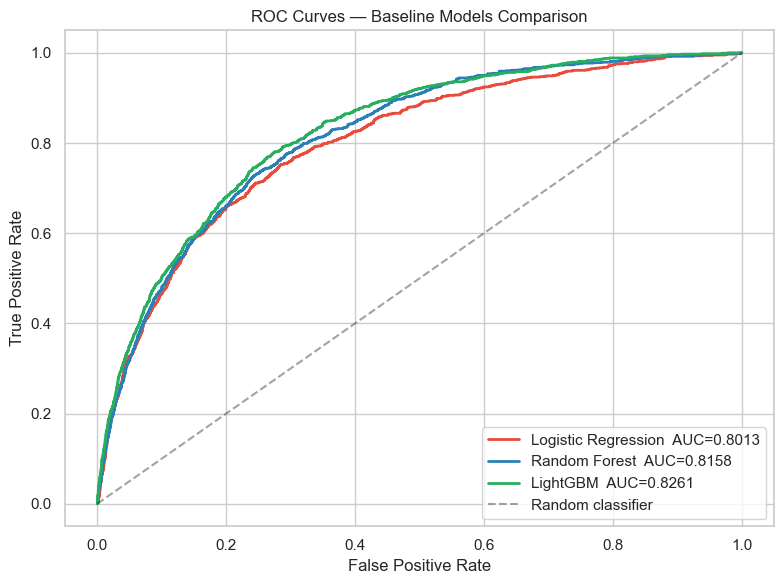

              Model      CV ROC-AUC Val ROC-AUC Val Avg Precision
Logistic Regression 0.7892 ± 0.0052      0.8013            0.2674
      Random Forest 0.8023 ± 0.0030      0.8158            0.2831
           LightGBM 0.8087 ± 0.0077      0.8261            0.3125


In [7]:
plt.figure(figsize=(8, 6))

colors = ['#e74c3c', '#2980b9', '#27ae60']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['proba'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name}  AUC={res['val_auc']:.4f}")

plt.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Baseline Models Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame([
    {
        'Model': name,
        'CV ROC-AUC': f"{res['cv_auc']:.4f} ± {res['cv_std']:.4f}",
        'Val ROC-AUC': f"{res['val_auc']:.4f}",
        'Val Avg Precision': f"{res['val_ap']:.4f}"
    }
    for name, res in results.items()
])
print(summary.to_string(index=False))

### 6. Feature Importance

We plot feature importances from the best tree-based model.
This helps us understand which features matter most and guides Sprint 3 improvements.


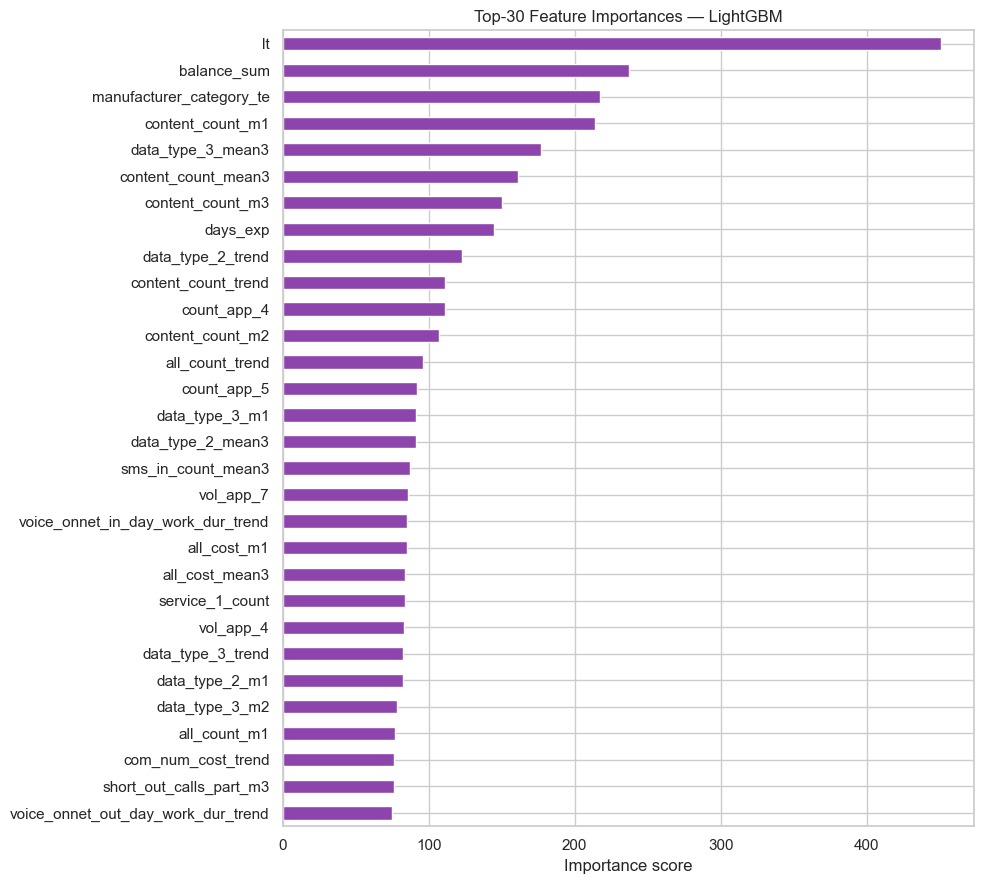

Top-15 most important features:
lt                          451
balance_sum                 237
manufacturer_category_te    217
content_count_m1            214
data_type_3_mean3           177
content_count_mean3         161
content_count_m3            150
days_exp                    145
data_type_2_trend           123
count_app_4                 111
content_count_trend         111
content_count_m2            107
all_count_trend              96
count_app_5                  92
data_type_3_m1               91


In [8]:
# Use LightGBM if available, otherwise Random Forest
best_tree = results.get('LightGBM', results.get('Random Forest', None))
best_name = 'LightGBM' if 'LightGBM' in results else 'Random Forest'

if best_tree and 'model' in best_tree:
    model = best_tree['model']
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top30 = importances.nlargest(30)

    plt.figure(figsize=(10, 9))
    top30.sort_values().plot(kind='barh', color='#8e44ad')
    plt.title(f'Top-30 Feature Importances — {best_name}')
    plt.xlabel('Importance score')
    plt.tight_layout()
    plt.show()

    print('Top-15 most important features:')
    print(top30.head(15).to_string())
else:
    print('No tree model available for feature importance.')

### 7. Error Analysis

We analyse where the best model makes mistakes.
Confusion matrix + classification report at the default 0.5 threshold
and at an **optimised threshold** that maximises F1 on the validation set.


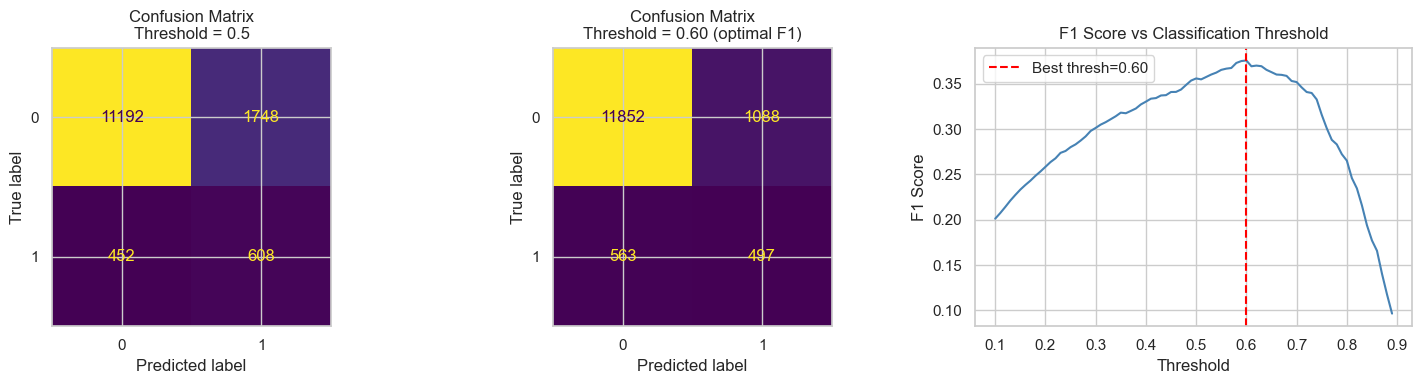

=== LightGBM at threshold = 0.5 ===
              precision    recall  f1-score   support

      No sub       0.96      0.86      0.91     12940
  Subscribed       0.26      0.57      0.36      1060

    accuracy                           0.84     14000
   macro avg       0.61      0.72      0.63     14000
weighted avg       0.91      0.84      0.87     14000

=== LightGBM at threshold = 0.60 (optimal F1) ===
              precision    recall  f1-score   support

      No sub       0.95      0.92      0.93     12940
  Subscribed       0.31      0.47      0.38      1060

    accuracy                           0.88     14000
   macro avg       0.63      0.69      0.66     14000
weighted avg       0.91      0.88      0.89     14000



In [9]:
best_name_key = 'LightGBM' if 'LightGBM' in results else 'Random Forest'
best_proba = results[best_name_key]['proba']

# Default threshold = 0.5
y_pred_05 = (best_proba >= 0.5).astype(int)

# Optimal threshold by F1
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (best_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_opt = (best_proba >= best_thresh).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix — default
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_05, ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix\nThreshold = 0.5')

# Confusion matrix — optimised
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_opt, ax=axes[1], colorbar=False)
axes[1].set_title(f'Confusion Matrix\nThreshold = {best_thresh:.2f} (optimal F1)')

# F1 vs threshold
axes[2].plot(thresholds, f1_scores, color='steelblue')
axes[2].axvline(best_thresh, color='red', linestyle='--', label=f'Best thresh={best_thresh:.2f}')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score vs Classification Threshold')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'=== {best_name_key} at threshold = 0.5 ===')
print(classification_report(y_val, y_pred_05, target_names=['No sub', 'Subscribed']))

print(f'=== {best_name_key} at threshold = {best_thresh:.2f} (optimal F1) ===')
print(classification_report(y_val, y_pred_opt, target_names=['No sub', 'Subscribed']))

### 8. Results Summary

In [10]:
print('=== SPRINT 2 BASELINE RESULTS ===')
for name, res in results.items():
    print(f"{name:25s}  CV AUC={res['cv_auc']:.4f} ± {res['cv_std']:.4f}  Val AUC={res['val_auc']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['val_auc'])
best_auc = results[best_model_name]['val_auc']
print(f'\nBest model: {best_model_name}  (Val AUC = {best_auc:.4f})')

# Save best threshold for Sprint 3
os.makedirs('../data/processed', exist_ok=True)
pd.Series({'best_model': best_model_name, 'best_threshold': best_thresh, 'best_val_auc': best_auc}).to_json('../data/processed/baseline_results.json')
print('Baseline results saved to ../data/processed/baseline_results.json')

=== SPRINT 2 BASELINE RESULTS ===
Logistic Regression        CV AUC=0.7892 ± 0.0052  Val AUC=0.8013
Random Forest              CV AUC=0.8023 ± 0.0030  Val AUC=0.8158
LightGBM                   CV AUC=0.8087 ± 0.0077  Val AUC=0.8261

Best model: LightGBM  (Val AUC = 0.8261)
Baseline results saved to ../data/processed/baseline_results.json


#### Sprint 2 Baseline Summary

| Model | CV ROC-AUC | Val ROC-AUC | Val Avg Precision | Notes |
|---|---|---|---|---|
| Logistic Regression | 0.7892 ± 0.0052 | 0.8013 | 0.2674 | Linear baseline; scaled features |
| Random Forest | 0.8023 ± 0.0030 | 0.8158 | 0.2831 | Tree ensemble; `class_weight='balanced'` |
| **LightGBM** | **0.8087 ± 0.0077** | **0.8261** | **0.3125** | Gradient boosting; `scale_pos_weight`; **best** |

**Best model: LightGBM** — Val ROC-AUC = **0.8261**

**Key observations:**
- All 3 models significantly beat the 0.5 random baseline — features are informative
- LightGBM outperforms LR by +0.037 AUC — confirms non-linear relationships in the data
- CV and Val AUC are close → no significant overfitting
- At optimal threshold (0.60), Subscribed class F1 = 0.38 — still room to improve
- Top features: `lt`, `balance_sum`, `manufacturer_category_te`, `content_count_m1`

#### What to improve in Sprint 3
- Hyperparameter tuning (Optuna / GridSearchCV) for LightGBM
- Feature selection — remove low-importance features to reduce 574→~200 cols
- Try XGBoost / CatBoost
- Explore SMOTE for class imbalance
- Threshold optimisation for business objective (Recall vs Precision tradeoff)
- Dimensionality reduction (PCA) experiment